### Importação das bibliotecas

In [45]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

### Análise de Dados

In [46]:
df_order_reviews = pd.read_csv(f"{os.getcwd()}\\documentos\\olist_order_reviews_dataset.csv")
df_order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


O dataset apresenta dados nulos no título e nos comentários, porém nas notas da review se mantém ativas

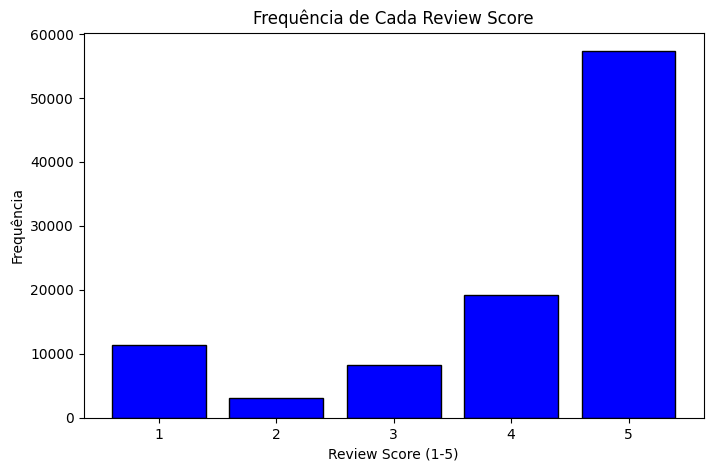

In [47]:
# Avaliação da Frequência de Cada Review
df_score_frequency = (
    df_order_reviews[['review_score']]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(df_score_frequency.index.get_level_values('review_score'),
        df_score_frequency.values, color='blue', edgecolor='black')
plt.title("Frequência de Cada Review Score")
plt.xlabel("Review Score (1-5)")
plt.ylabel("Frequência")
plt.show()

Nessa versão abaixo, o order_reviews apresenta titulos similares, porém com letras maiúsculas, portanto para simplificar as frequências, será colocado o texto em caixa minúscula

In [48]:
df_reviews_title_frequency = (
    df_order_reviews[['review_comment_title']].value_counts()
).reset_index(name="frequency")

df_reviews_title_frequency[df_reviews_title_frequency['frequency'] > 1]

,review_comment_title,frequency
0,Recomendo,423
1,recomendo,345
2,Bom,293
3,super recomendo,270
4,Excelente,248
...,...,...
759,amei,2
760,Produto muito bom!,2
761,Muito bonita,2
762,Entrega super rápida!,2


A coluna 'review_comment_message' apresenta textos semelhantes porém com acentuação ou começa com letra maiúscula

In [49]:
# Avaliação da Frequência dos comentários 
df_reviews_title_frequency = (
    df_order_reviews[['review_comment_message']].value_counts()
).reset_index(name="frequency")

df_reviews_title_frequency[df_reviews_title_frequency['frequency'] > 1]

,review_comment_message,frequency
0,Muito bom,230
1,Bom,189
2,muito bom,122
3,bom,107
4,Recomendo,100
...,...,...
1177,Entrega super rápida,2
1178,"Ótimo, excelente, recomendo a todos",2
1179,Estou aguardando a encomenda. \r\nRecebi o avi...,2
1180,Super recomendo!!!!!,2


#### Avaliação das Reviews Nulas

In [50]:
df_filtrado = df_order_reviews[df_order_reviews['review_comment_message'].isna()][
    ['order_id', 'review_score', 'review_comment_title', 'review_comment_message']
]

df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 58247 entries, 0 to 99222
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   order_id                58247 non-null  str  
 1   review_score            58247 non-null  int64
 2   review_comment_title    1729 non-null   str  
 3   review_comment_message  0 non-null      str  
dtypes: int64(1), str(3)
memory usage: 4.0 MB


In [51]:
# Como o título nulo e as mensagens nulas nos casos filtrados poderia avaliar por meio da nota que não estão nulos

df_filtrado[df_filtrado['review_comment_title'].isna()]

,order_id,review_score,review_comment_title,review_comment_message
0,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN
1,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN
2,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN
5,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN
6,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN
...,...,...,...,...
99217,48f7ee67313eda32bfcf5b9c1dd9522d,5,NaN,NaN
99218,d699c734a0b1c8111f2272a3f36d398c,5,NaN,NaN
99219,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN
99220,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN


#### Avaliação do Tamanho das Mensagens e dos Títulos

In [52]:
df_avaliacao_textos = df_order_reviews[['review_id','review_comment_message', 'review_comment_title']]

df_avaliacao_textos['title_lenght'] = df_avaliacao_textos['review_comment_title'].str.len()
df_avaliacao_textos['message_lenght'] = df_avaliacao_textos['review_comment_message'].str.len()

# Avaliação da frequência dos tamanhos dos títulos
df_title_length_frequency = (
    df_avaliacao_textos['title_lenght'].value_counts()\
    .reset_index(name='frequency').sort_values(by='title_lenght', ascending=True)
)
display(df_title_length_frequency)


# Avaliação da frequência dos tamanhos das mensagens
df_message_length_frequency = (
    df_avaliacao_textos['message_lenght'].value_counts()\
    .reset_index(name='frequency').sort_values(by='message_lenght', ascending=True)
)
display(df_message_length_frequency)


,title_lenght,frequency
24,1.0,162
19,2.0,250
4,3.0,627
20,4.0,243
2,5.0,846
6,6.0,485
12,7.0,364
14,8.0,346
0,9.0,1724
3,10.0,840


,message_lenght,frequency
124,1.0,103
83,2.0,199
3,3.0,475
113,4.0,123
7,5.0,454
...,...,...
202,204.0,16
205,205.0,1
206,206.0,1
207,207.0,1


Pelas verificações dos tamanhos dos textos das mensagens, existem casos onde as mensagens apresentam um tamanho menor que 3, representando mensagens de Ok uma letra ou emojis

In [53]:
df_shorter_messages = df_avaliacao_textos[df_avaliacao_textos['message_lenght'] <= 2][
                                                                                        ['review_comment_message', 'review_comment_title']
                                                                                    ].drop_duplicates()

print("Mensagens Únicas")
print(pd.unique(df_shorter_messages['review_comment_message']), "\n\n")

print("Titulos Únicos")
print(pd.unique(df_shorter_messages['review_comment_title']))

Mensagens Únicas
<ArrowStringArray>
[  'OK',    'A',   '10',    'X',   'Ok',   '**',    '.',   'ok',   'Hh',
    '👍',   '..', '\r\n',    'x',    '😀',   'Sh',    '*',   'xx',   'cc',
    ',',   ':(',    's',   'Oi',   'io',    ' ',    '9',   '👍🏻',    '?',
   ':)',    '0',    '-',   ' N',    'I',    'S',   '00',    'm',    '5',
    'B',    't',   'Ol',    'O',    'W',    'L',   '08',    'o',    '👎',
   'ND',    '8',    'Y',    'K',    '4']
Length: 50, dtype: str 


Titulos Únicos
<ArrowStringArray>
[                        nan,                         'X',
                        'Ok',                        'ok',
                 'Muito bom',                       'bom',
                     'Ótima',                 'REcomendo',
   'Ótima loja, recomendo 😀',                'recomendo ',
                        'xx',                       'aaa',
                         ',',                       'Bom',
                        '10',                 'Excelente',
                         '

### Distribuição de Sentimento

In [54]:
df_order_reviews['feeling_state'] = df_order_reviews['review_score'].map(
    lambda x: 'negativo' if (x <= 2) else 'positivo' if (x > 3) else 'neutro'
)

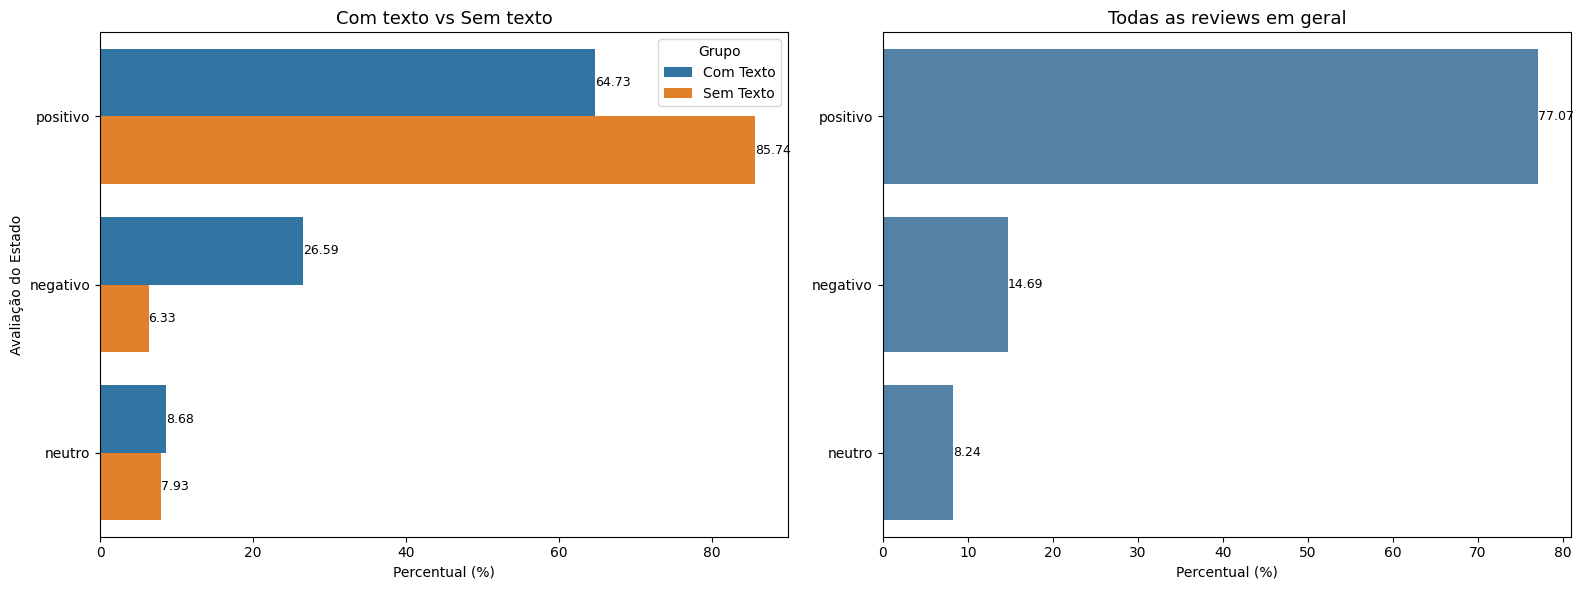

In [55]:
# Adaptação das mensagens dos textos
with_text_message = (
                    df_order_reviews['review_comment_message']\
                    .fillna('')\
                    .astype("str")\
                    .str.strip().ne('')
                )

# Filtro dos casos cujo o texto da mensagem esteja nulo ou preenchido
df_with_text = df_order_reviews.loc[with_text_message].copy()
df_without_text = df_order_reviews.loc[~with_text_message].copy()

# Função para calcular a frequência e percentual do feeling state
def create_frequency(df, rotulo):
    freq = (df['feeling_state'].value_counts().reset_index(name='frequency'))

    # Calculo percentual
    freq['percent'] = round(freq['frequency'] / freq['frequency'].sum() * 100, 2)
    freq['flag'] = rotulo
    return freq


freq_with_text = create_frequency(df_with_text, "Com Texto")
freq_without_text = create_frequency(df_without_text, "Sem Texto")
all_frequency = create_frequency(df_order_reviews.copy(), "Todos os Casos")

# Plot de 2 Subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Agregação das Frequencias com ou sem texo
df_comp = pd.concat([freq_with_text, freq_without_text], ignore_index=True)

sns.barplot(data=df_comp, x='percent', y='feeling_state', hue='flag', ax=axes[0])
axes[0].set_title('Com texto vs Sem texto', fontsize=13)
axes[0].set_xlabel('Percentual (%)')
axes[0].set_ylabel('Avaliação do Estado')
axes[0].legend(title='Grupo')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt= "%.2f", fontsize=9)


# Agregação da Frequência de todos os textos
sns.barplot(data=all_frequency, x='percent', y='feeling_state', ax=axes[1], color='steelblue')
axes[1].set_title('Todas as reviews em geral', fontsize=13)
axes[1].set_xlabel('Percentual (%)')
axes[1].set_ylabel('')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt= "%.2f", fontsize=9)

plt.tight_layout()
plt.show()

Mediante a essas análises percebe-se que a quantidade positiva de reviews sem texto apresenta um percentual maior que as outras classificações, e quando se filtra reviews sem texto aparentemente possui um percentual menor  

### Limpeza de Métricas

In [56]:
df = df_order_reviews.copy()

# Criação do Texto crú
df['text_raw'] = df['review_comment_message'].fillna('').astype('str')

In [57]:
# Validação se há algum caracter indevido

# Regex que descobre os principais blocos de emoji
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\u2600-\u27BF"
    "]"
)

df['is_nan'] = df['text_raw'].isna()
df['is_empty'] = df['text_raw'].str.strip().eq('')
df['has_url'] = df['text_raw'].str.contains(r'https?://\S+|www\.\S+', regex=True)
df['has_html'] = df['text_raw'].str.contains(r'<[^>]+>', regex=True)
df['has_newline'] = df['text_raw'].str.contains(r'[\r\n\t]', regex=True)
df['has_emoji'] =  df['text_raw'].str.contains(EMOJI_RE, regex=True)

def clean_text(txt):
    txt = re.sub(r'http\S+|www\.\S+', ' ', txt) # Substituição do Ícone de HTTP
    txt = re.sub(r'<.*?>', ' ', txt) # Substituição de HTML
    txt = re.sub(r'[\r\n\t]+', ' ', txt) # Substituição de Espaços em branco
    txt = re.sub(r'[^\w\sáéíóúâêôãõàç]', ' ', txt) # Substituição de Caracteres especiais
    txt = re.sub(r'\d+', ' ', txt) # Substituição de Dígitos Numéricos 
    txt = re.sub(r'\s+', ' ', txt)  # Remoção dos espaços em branco
    return txt.strip()


# Limpeza Textual
df['text_clean'] = df['text_raw'].apply(clean_text)
df['text_clean_is_empty'] = df['text_clean'].eq('')


# Resumo por classe
df_text_info = df.groupby('feeling_state').agg(
                    n = ('text_raw', 'size'),
                    is_nan = ('is_nan', 'sum'),
                    is_empty_strip = ('is_empty', 'sum'),
                    is_empty_clean = ('text_clean_is_empty', 'sum'),
                    has_url = ('has_url', 'sum'),
                    has_html = ('has_html', 'sum'),
                    has_emoji = ('has_emoji', 'sum')
                )

for col in [x for x in df_text_info.columns if x != 'n']:
    df_text_info[f'pct_{col}'] = ((df_text_info[col]/df_text_info['n']) * 100).round(2)

display(df_text_info)

,n,is_nan,is_empty_strip,is_empty_clean,has_url,has_html,has_emoji,pct_is_nan,pct_is_empty_strip,pct_is_empty_clean,pct_has_url,pct_has_html,pct_has_emoji
feeling_state,,,,,,,,,,,,,
negativo,14575,0,3686,3697,1,0,27,0.0,25.29,25.37,0.01,0.0,0.19
neutro,8179,0,4623,4633,0,0,10,0.0,56.52,56.65,0.00,0.0,0.12
positivo,76470,0,49965,50103,1,0,236,0.0,65.34,65.52,0.00,0.0,0.31


In [58]:
df[df['has_url'] == True][['review_score', 'review_comment_title', 'review_comment_message', 'text_raw', 'text_clean']]

,review_score,review_comment_title,review_comment_message,text_raw,text_clean
25360,2,as cores não corresponde,comprei o produto pela cor ilustrada pelo site...,comprei o produto pela cor ilustrada pelo site...,comprei o produto pela cor ilustrada pelo site...
77494,4,NaN,Loja parceira de www.lannister.com e por isso ...,Loja parceira de www.lannister.com e por isso ...,Loja parceira de e por isso merecedora de crédito


In [59]:
df[df['has_emoji'] == True][['review_score', 'review_comment_title', 'review_comment_message', 'text_raw', 'text_clean']]

,review_score,review_comment_title,review_comment_message,text_raw,text_clean
314,5,10,Cada vez que compro mais fico satisfeita parab...,Cada vez que compro mais fico satisfeita parab...,Cada vez que compro mais fico satisfeita parab...
544,2,NaN,"Comprei o produto, paguei no boleto e só receb...","Comprei o produto, paguei no boleto e só receb...",Comprei o produto paguei no boleto e só recebi...
566,5,NaN,Perfeitos😁,Perfeitos😁,Perfeitos
630,5,NaN,Parabéns 😤 pelo excelente atendimento de quali...,Parabéns 😤 pelo excelente atendimento de quali...,Parabéns pelo excelente atendimento de qualidade
644,5,Super satisfeita.,"Produto perfeito, entrega rápida. Estou satisf...","Produto perfeito, entrega rápida. Estou satisf...",Produto perfeito entrega rápida Estou satisfei...
...,...,...,...,...,...
96770,5,NaN,👍🏻👌🏻👏🏻,👍🏻👌🏻👏🏻,
98067,3,NaN,É bem bonita e bem acabada mais pena q veio a ...,É bem bonita e bem acabada mais pena q veio a ...,É bem bonita e bem acabada mais pena q veio a ...
98543,5,NaN,Chegou muito obrigado antes do prazo 👏👏,Chegou muito obrigado antes do prazo 👏👏,Chegou muito obrigado antes do prazo
98779,5,Ótimo,👍👍👍👍👍👍👍👍👏👏👏👏👏👏👏👏,👍👍👍👍👍👍👍👍👏👏👏👏👏👏👏👏,


Avaliação das respostas curtas

In [60]:
df['len_clean'] = df['text_clean'].str.len()

df['number_tokens'] = df['text_clean'].str.split().str.len()
df['number_tokens_raw'] = df['text_raw'].str.split().str.len()

df_short_raw = df[(df['number_tokens_raw'] > 0) & (df['number_tokens_raw'] <= 2)]
print(f"≤2 tokens no texto original: {len(df_short_raw)} ({len(df_short_raw)/len(df)*100:.2f}%)")

# curtas no texto limpo
df_short_clean= df[(df['number_tokens'] > 0) & (df['number_tokens'] <= 2)]
print(f"≤2 tokens após limpeza:      {len(df_short_clean)} ({len(df_short_clean)/len(df)*100:.2f}%)")

≤2 tokens no texto original: 5645 (5.69%)
≤2 tokens após limpeza:      5544 (5.59%)


In [61]:
display(df_short_raw[['text_raw', 'number_tokens_raw']])

,text_raw,number_tokens_raw
19,Péssimo,1
36,"Recomendo ,",2
37,muito boa,2
55,boa,1
59,MT lindo,2
...,...,...
99063,Ótimo,1
99109,otimo,1
99140,Muito bom,2
99172,Satisfeita,1


In [62]:
display(df_short_clean[['text_clean', 'number_tokens', 'len_clean']])

,text_clean,number_tokens,len_clean
19,Péssimo,1,7
22,Loja nota,2,9
36,Recomendo,1,9
37,muito boa,2,9
55,boa,1,3
...,...,...,...
99063,Ótimo,1,5
99109,otimo,1,5
99140,Muito bom,2,9
99172,Satisfeita,1,10


#### Avaliação de duplicatas

,total,unique_raw,unique_clean,dup_raw,dup_clean,dup_percent_raw,dup_percent_clean
feeling_state,,,,,,,
negativo,10878,10476,10296,402,582,3.70,5.35
neutro,3546,3377,3317,169,229,4.77,6.46
positivo,26367,22476,21095,3891,5272,14.76,19.99


,text_clean,frequency
0,Muito bom,402
1,Bom,234
2,Recomendo,226
3,Ótimo,175
4,muito bom,162
5,Excelente,155
6,bom,118
7,Otimo,117
8,otimo,112
9,Ótimo produto,108


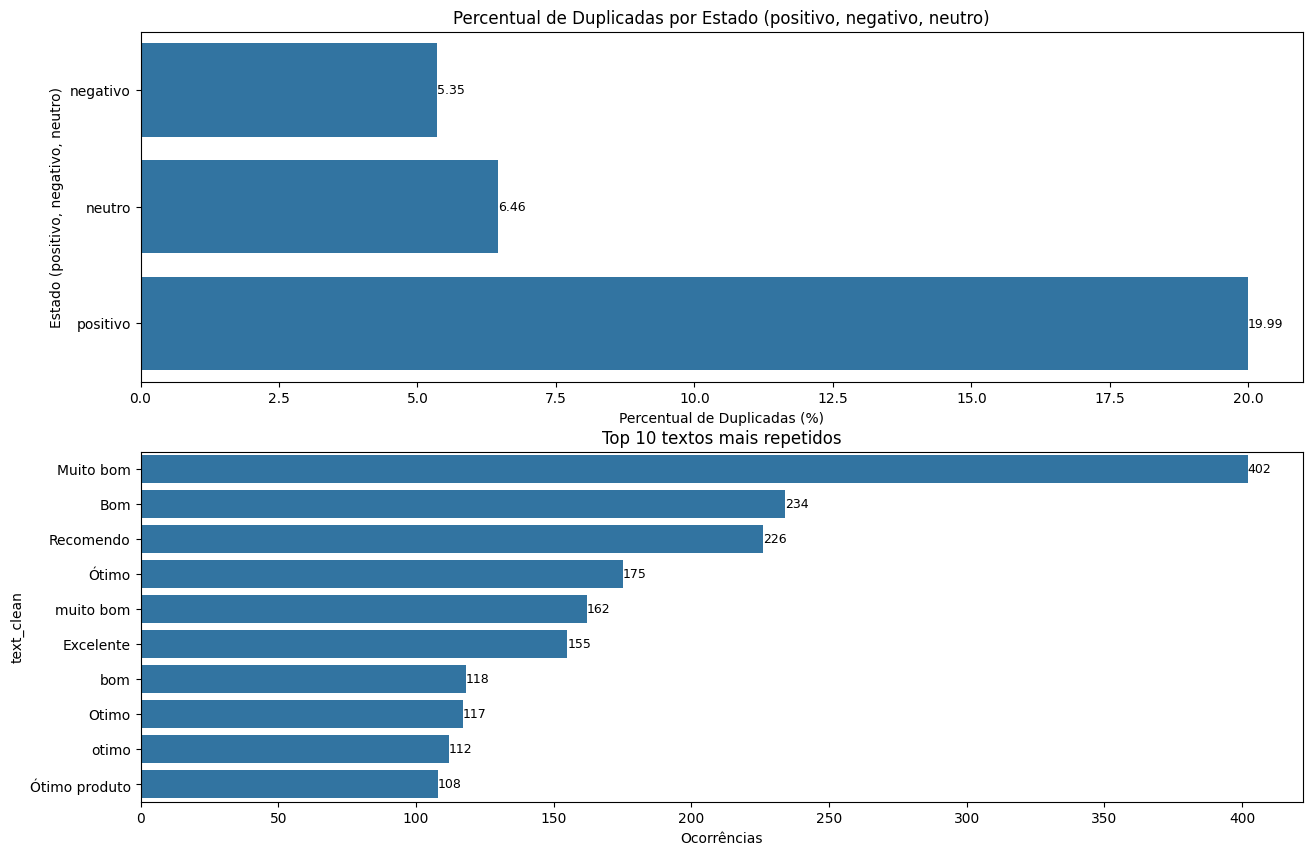

In [63]:
# Filtragem de textos limpos não nulos
df_valid = df.loc[~df['text_clean_is_empty'] & ~df['is_empty']]

# Verificação das duplicadas do texto bruto
dup_raw = df_valid[(df_valid.duplicated(subset='text_raw'))].sort_values(by='text_raw')

# Verificação das duplicadas do texto bruto
dup_clean = df_valid[(df_valid.duplicated(subset='text_clean'))].sort_values(by='text_clean')


# Verificação do Resumo de duplicadas
resumo_dup = (
    df_valid.groupby("feeling_state").agg(
        total = ("text_raw", "size"),
        unique_raw = ("text_raw", "nunique"),
        unique_clean = ("text_clean", "nunique")
    )
)

# Verificação do percentual de duplicadas
resumo_dup['dup_raw'] = resumo_dup['total'] - resumo_dup['unique_raw']
resumo_dup['dup_clean'] = resumo_dup['total'] - resumo_dup['unique_clean']
resumo_dup['dup_percent_raw'] = round((resumo_dup['dup_raw']/resumo_dup['total']) * 100, 2)
resumo_dup['dup_percent_clean'] = round((resumo_dup['dup_clean']/resumo_dup['total']) * 100, 2)
display(resumo_dup)


# Top 10 textos repetidos
df_top10_repeated = df_valid['text_clean'].value_counts().reset_index(name='frequency').sort_values(by='frequency', ascending=False)[:10]
display(df_top10_repeated)

# Criação de Gráficos
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

sns.barplot(data=resumo_dup.reset_index(), x='dup_percent_clean', y='feeling_state', ax=axes[0])
axes[0].set_title("Percentual de Duplicadas por Estado (positivo, negativo, neutro)")
axes[0].set_xlabel("Percentual de Duplicadas (%)")
axes[0].set_ylabel("Estado (positivo, negativo, neutro)")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt= "%.2f", fontsize=9)


sns.barplot(data=df_top10_repeated, x='frequency', y='text_clean', ax=axes[1])
axes[1].set_title("Top 10 textos mais repetidos")
axes[1].set_xlabel("Ocorrências")

for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)


Avaliação do Cumprimento do Texto por Sentimento

<Axes: xlabel='feeling_state', ylabel='len_clean'>

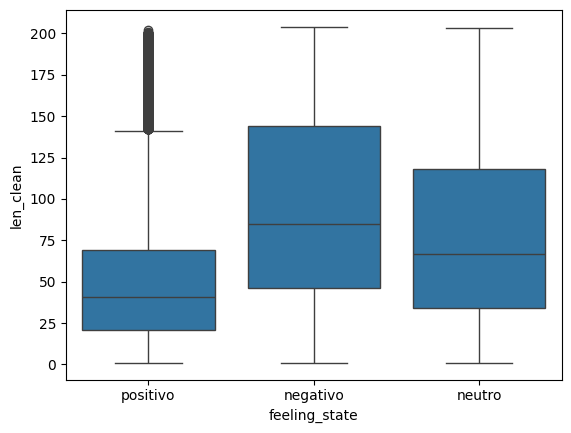

In [64]:
sns.boxplot(data=df[df['len_clean']>0], x='feeling_state', y='len_clean')

#### Avaliação de Ruídos

Apesar das notas altas, existe a possibilidade de haver um ruído de notas altas com mensagens negativas

In [65]:
positive_review = r'\b(ótimo|excelente|perfeito|recomendo|maravilha|amei|adorei|parabéns)\b'
negative_review = r'\b(não|péssimo|ruim|horrível|defeito|atraso|nunca|quebrado|terrível)\b'

df['has_negative_review'] = df['text_clean'].str.contains(negative_review, case=False)
df['has_positive_review'] = df['text_clean'].str.contains(positive_review, case=False)


pd.crosstab(df['feeling_state'], [df['has_positive_review'], df['has_negative_review']])

C:\Users\rpf97\AppData\Local\Temp\ipykernel_21292\179309207.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_negative_review'] = df['text_clean'].str.contains(negative_review, case=False)
C:\Users\rpf97\AppData\Local\Temp\ipykernel_21292\179309207.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_positive_review'] = df['text_clean'].str.contains(positive_review, case=False)


has_positive_review  False       True       
has_negative_review  False True  False True 
feeling_state                               
negativo              8263  5933    68   311
neutro                6820  1168   134    57
positivo             67001  1610  7532   327

In [66]:
df[(df['has_positive_review'] == True) & (df['has_negative_review'] == True)][['text_clean', 'has_negative_review', 'has_positive_review', 'review_score']]

,text_clean,has_negative_review,has_positive_review,review_score
267,Recebi bem rápido porém veio outro produto e n...,True,True,1
320,Produto não recomendo não ler em nenhum dispos...,True,True,1
345,Recebi meu produto corretamente e dentro do pr...,True,True,5
430,quanto ao site não tenho o que questionar semp...,True,True,5
528,Gostei muito do produto a entrega veio antes d...,True,True,5
...,...,...,...,...
98227,Recomendo mas não foi entregue na data previst...,True,True,4
98510,Ainda não usei mas chegou antes do prazo e em ...,True,True,4
98617,Comprei um carregador com tomada lightning par...,True,True,1
98650,Amei o produto A entrega nunca vi tão rápido c...,True,True,5


In [67]:
df[(df['has_positive_review'] == False) & (df['has_negative_review'] == False)][['text_clean', 'has_negative_review', 'has_positive_review', 'review_score']]

,text_clean,has_negative_review,has_positive_review,review_score
0,,False,False,4
1,,False,False,5
2,,False,False,5
3,Recebi bem antes do prazo estipulado,False,False,5
5,,False,False,1
...,...,...,...,...
99217,,False,False,5
99218,,False,False,5
99219,,False,False,5
99220,,False,False,5


In [68]:
df[(df['feeling_state'] == 'positivo') & (df['has_negative_review'] == True)][['text_clean', 'has_negative_review', 'review_score']]

,text_clean,has_negative_review,review_score
166,Se fosse vidro tinha quebrado veio na caixa se...,True,4
170,Espero receber esta semana o que não seria tão...,True,5
199,Ainda não tive a oportunidade de testar,True,5
236,Uma das peças não encaixava estava de diâmetro...,True,4
345,Recebi meu produto corretamente e dentro do pr...,True,5
...,...,...,...
98940,Celular é bom só não gostei do carregador poqu...,True,4
99003,É bom só não dei nota máxima porque o som é ba...,True,4
99004,Chegou bem antes do prazo O único defeito e o ...,True,4
99048,Atendimento e envio super recomendado Produto ...,True,5


In [69]:
df[(df['feeling_state'] == 'negativo') & (df['has_negative_review'] == False)][['text_clean', 'has_negative_review', 'review_score']]

,text_clean,has_negative_review,review_score
5,,False,1
16,GOSTARIA DE SABER O QUE HOUVE SEMPRE RECEBI E ...,False,2
39,Nada de chegar o meu pedido,False,1
40,,False,2
41,,False,1
...,...,...,...
99155,Eu recebi o seguinte email e preciso saber com...,False,1
99174,,False,2
99184,,False,1
99200,Foto muito diferente principalmente a graninha...,False,2


#### Avaliação de Problemas Específicos

In [70]:
specific_problems = {
    "delivery": r"(não recebi|não recebido|não chegou|não foi entregue)",
    "delayed": r"atras",
    'deffect': r'defeito|quebrado|danificado',
    "wrong_product": r'(cor errada|produto errado|tamanho errado)'
}

for key, value in specific_problems.items():
    df[f'{key}_prob'] = df['text_clean'].str.contains(value, case=False)


pd.crosstab(df['feeling_state'], [df[f'{x}_prob']  for x in specific_problems.keys()])


C:\Users\rpf97\AppData\Local\Temp\ipykernel_21292\1266162781.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f'{key}_prob'] = df['text_clean'].str.contains(value, case=False)
C:\Users\rpf97\AppData\Local\Temp\ipykernel_21292\1266162781.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f'{key}_prob'] = df['text_clean'].str.contains(value, case=False)


delivery_prob       False                                     True         \
delayed_prob        False                   True              False         
deffect_prob        False       True        False       True  False         
wrong_product_prob  False True  False True  False True  False False True    
feeling_state                                                               
negativo            11405   112   401     5   219     1     2  2350     4   
neutro               7778    25    90     0    55     0     2   219     0   
positivo            76046    19   128     0   120     0     1   150     0   

delivery_prob                   
delayed_prob             True   
deffect_prob       True  False  
wrong_product_prob False False  
feeling_state                   
negativo               8    68  
neutro                 1     9  
positivo               2     4

#### Checklist

In [71]:
total         = len(df)
n_nan         = df['is_nan'].sum()
n_empty_strip = df['is_empty'].sum()
n_empty_clean = df['text_clean_is_empty'].sum()
n_url         = df['has_url'].sum()
n_html        = df['has_html'].sum()
n_newline     = df['has_newline'].sum()
n_dup_clean   = df_valid['text_clean'].duplicated().sum()
n_short       = (df_valid['len_clean'] <= 2).sum()


print(f'Percentual de Valores Nulos: {round(n_nan/total * 100, 2)} %')
print(f'Percentual de Strings Vazias: {round(n_empty_strip/total * 100, 2)} %')
print(f'Percentual de Strings Vazias de Texto Limpo: {round(n_empty_clean/total * 100, 2)} %')
print(f'Percentual de Strings com URL: {round(n_url/total * 100, 2)} %')
print(f'Percentual de Strings com HTML: {round(n_html/total * 100, 2)} %')
print(f'Percentual de Strings com Quebra de Linha: {round(n_newline/total * 100, 2)} %')
print(f'Percentual de Strings Limpas Duplicadas: {round(n_dup_clean/total * 100, 2)} %')
print(f'Percentual de Strings Limpas Curtas: {round(n_short/total * 100, 2)} %')

Percentual de Valores Nulos: 0.0 %
Percentual de Strings Vazias: 58.73 %
Percentual de Strings Vazias de Texto Limpo: 58.89 %
Percentual de Strings com URL: 0.0 %
Percentual de Strings com HTML: 0.0 %
Percentual de Strings com Quebra de Linha: 3.88 %
Percentual de Strings Limpas Duplicadas: 6.38 %
Percentual de Strings Limpas Curtas: 0.19 %
